<a href="https://colab.research.google.com/github/Uwimpaye-yve/brazilian-ecommerce-delivery-analysis/blob/main/brazilian.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import os

os.environ['KAGGLE_API_TOKEN'] = 'KGAT_8bc3df1f2e72f659b1d3b07f30643d10'

# 2. Download the Olist Dataset
!kaggle datasets download -d olistbr/brazilian-ecommerce

# 3. Unzip the files into a folder
!unzip -q brazilian-ecommerce.zip -d olist_data

# 4. Check if files are there
print("Files downloaded successfully:", os.listdir('olist_data'))

Dataset URL: https://www.kaggle.com/datasets/olistbr/brazilian-ecommerce
License(s): CC-BY-NC-SA-4.0
100% 42.6M/42.6M [00:00<00:00, 195MB/s]

Files downloaded successfully: ['olist_order_payments_dataset.csv', 'olist_order_items_dataset.csv', 'olist_geolocation_dataset.csv', 'olist_sellers_dataset.csv', 'olist_orders_dataset.csv', 'olist_customers_dataset.csv', 'olist_order_reviews_dataset.csv', 'olist_products_dataset.csv', 'product_category_name_translation.csv']


In [2]:
import pandas as pd

# Load the core CSVs
path = 'olist_data/'
orders = pd.read_csv(path + 'olist_orders_dataset.csv')
reviews = pd.read_csv(path + 'olist_order_reviews_dataset.csv')
customers = pd.read_csv(path + 'olist_customers_dataset.csv')

# --- STORY 1: THE SCHEMA BUILDER ---

# Join 1: Connect Orders to Customers (to get location data)
master_df = pd.merge(orders, customers, on='customer_id', how='inner')

# Join 2: Connect to Reviews (averaging scores per order to avoid duplicates)
reviews_avg = reviews.groupby('order_id')['review_score'].mean().reset_index()
master_df = pd.merge(master_df, reviews_avg, on='order_id', how='left')

print(f"Schema built! Total records: {len(master_df)}")
master_df[['order_id', 'customer_state', 'review_score']].head()

Schema built! Total records: 99441


,order_id,customer_state,review_score
0,e481f51cbdc54678b7cc49136f2d6af7,SP,4.0
1,53cdb2fc8bc7dce0b6741e2150273451,BA,4.0
2,47770eb9100c2d0c44946d9cf07ec65d,GO,5.0
3,949d5b44dbf5de918fe9c16f97b45f8a,RN,5.0
4,ad21c59c0840e6cb83a9ceb5573f8159,SP,5.0


In [3]:
# Convert columns to datetime
master_df['order_estimated_delivery_date'] = pd.to_datetime(master_df['order_estimated_delivery_date'])
master_df['order_delivered_customer_date'] = pd.to_datetime(master_df['order_delivered_customer_date'])

# Only audit delivered orders
audit_df = master_df[master_df['order_status'] == 'delivered'].copy()

# Calculate difference in days (Estimated - Actual)
# Positive = On Time/Early | Negative = Late
audit_df['days_diff'] = (audit_df['order_estimated_delivery_date'] - audit_df['order_delivered_customer_date']).dt.days

# Classify performance
def classify_delay(days):
    if days >= 0: return 'On Time'
    if days > -5: return 'Late'
    return 'Super Late'

audit_df['delivery_status'] = audit_df['days_diff'].apply(classify_delay)

print("Delay calculation complete!")
audit_df['delivery_status'].value_counts()

Delay calculation complete!


,count
delivery_status,
On Time,88644
Super Late,4672
Late,3162


/tmp/ipykernel_6995/552084643.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=state_worst_offenders.index, y=state_worst_offenders['Failure_Rate'], palette='Reds_r')


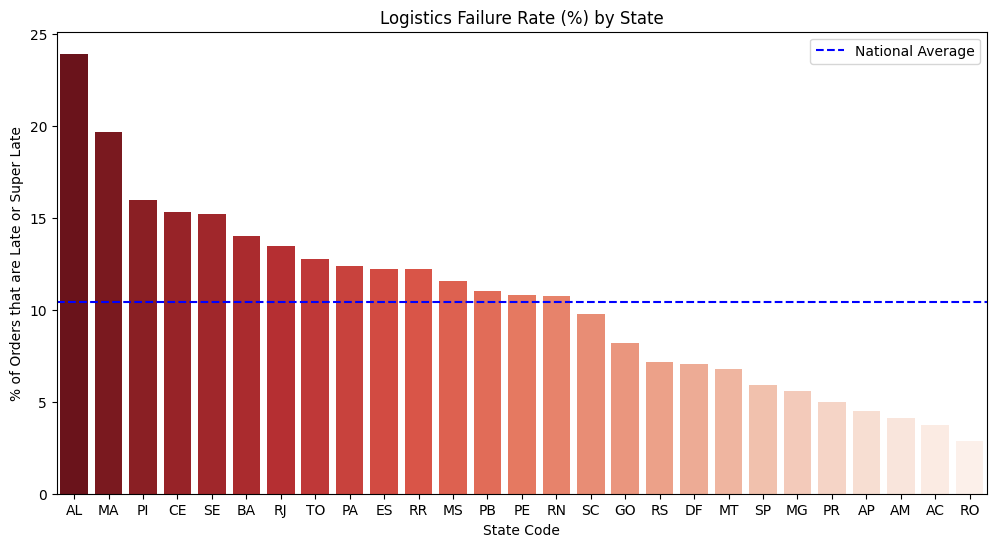

In [4]:
# 1. Calculate the % of delivery statuses per state
state_performance = audit_df.groupby('customer_state')['delivery_status'].value_counts(normalize=True).unstack().fillna(0)

# 2. Create a 'Failure Rate' (Late + Super Late)
state_performance['Failure_Rate'] = (state_performance.get('Late', 0) + state_performance.get('Super Late', 0)) * 100

# 3. Sort by the highest failure rate
state_worst_offenders = state_performance.sort_values('Failure_Rate', ascending=False)

# Visualize the Top 10 Worst States
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 6))
sns.barplot(x=state_worst_offenders.index, y=state_worst_offenders['Failure_Rate'], palette='Reds_r')
plt.title('Logistics Failure Rate (%) by State')
plt.ylabel('% of Orders that are Late or Super Late')
plt.xlabel('State Code')
plt.axhline(state_worst_offenders['Failure_Rate'].mean(), color='blue', linestyle='--', label='National Average')
plt.legend()
plt.show()

Average Scores:
delivery_status
On Time       4.294292
Late          3.595307
Super Late    1.859709
Name: review_score, dtype: float64


/tmp/ipykernel_6995/1174458624.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=sentiment_impact.index, y=sentiment_impact.values, palette='viridis')


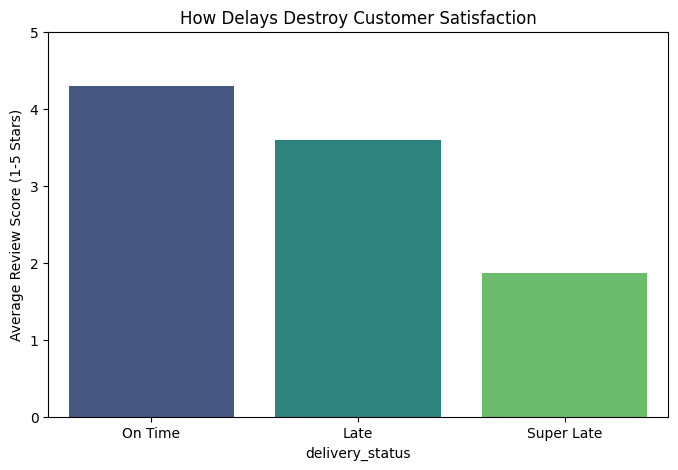

In [5]:
# Calculate Average Review Score per Delivery Status
sentiment_impact = audit_df.groupby('delivery_status')['review_score'].mean().sort_values(ascending=False)

plt.figure(figsize=(8, 5))
sns.barplot(x=sentiment_impact.index, y=sentiment_impact.values, palette='viridis')
plt.title('How Delays Destroy Customer Satisfaction')
plt.ylabel('Average Review Score (1-5 Stars)')
plt.ylim(0, 5) # Scale from 1 to 5 stars

# Print the specific numbers for your report
print("Average Scores:")
print(sentiment_impact)

In [6]:
# Calculate the average 'buffer' given to customers (Estimated Date - Purchase Date)
audit_df['order_purchase_timestamp'] = pd.to_datetime(audit_df['order_purchase_timestamp'])
audit_df['promised_window'] = (audit_df['order_estimated_delivery_date'] - audit_df['order_purchase_timestamp']).dt.days

# Check if 'Super Late' orders had a shorter promised window than 'On Time' orders
expectation_check = audit_df.groupby('delivery_status')['promised_window'].mean()
print("\nBusiness Insight: Average days promised to customer:")
print(expectation_check)


Business Insight: Average days promised to customer:
delivery_status
Late          19.519292
On Time       23.528372
Super Late    23.028253
Name: promised_window, dtype: float64


In [7]:
# Export the final audited data to a CSV
audit_df.to_csv('olist_delivery_audit_final.csv', index=False)

# Download it to your computer
from google.colab import files
files.download('olist_delivery_audit_final.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [8]:
# This creates a smaller, cleaner version of your audit data
small_audit = audit_df[['customer_state', 'delivery_status', 'review_score', 'days_diff']].copy()
small_audit.to_csv('final_audit_simple.csv', index=False)

from google.colab import files
files.download('final_audit_simple.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>